# 6CS012 - Worksheet 4: Fully Connected Neural Network for Devnagari Digit Classification

**Author:** Your Name  
**Module:** 6CS012 - Artificial Intelligence and Machine Learning

---

## What We Are Building
In this worksheet, we will:
1. Load and preprocess the Devnagari handwritten digit images
2. Build a Fully Connected Neural Network (FCN) using Keras
3. Train, evaluate, save and reload the model
4. Make predictions on unseen test images

---

In [ ]:
# Step 1: Mount Drive and unzip
from google.colab import drive
drive.mount('/content/drive')

import zipfile

zip_path = '/content/drive/MyDrive/Data Set /Copy of devnagari digit.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Unzipped!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipped!


## Step 0: Install & Import Libraries

Before we begin, make sure you have the required libraries installed.  
If you are using **Google Colab**, TensorFlow and Keras are already installed — skip the pip install line.

In [ ]:
# ── UNCOMMENT the line below if NOT using Google Colab ──
# !pip install tensorflow keras pillow scikit-learn matplotlib numpy

# ── Core libraries ──
import os                          # For navigating folder/file paths
import numpy as np                 # For numerical operations and arrays
import matplotlib.pyplot as plt    # For plotting graphs and images

# ── TensorFlow / Keras ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential       # To build a layer-by-layer model
from tensorflow.keras.layers import Dense, Flatten  # Dense = fully connected, Flatten = reshape
from tensorflow.keras.utils import to_categorical   # To one-hot encode labels

# ── Image loading ──
from PIL import Image              # Pillow: used to open and resize images

# ── Utilities ──
from sklearn.model_selection import train_test_split  # (Optional) for splitting data

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

✅ All libraries imported successfully!
TensorFlow version: 2.19.0
Keras version: 3.13.2


---
## Task 1: Data Preparation

### What is this step doing?
- We read images from folders on disk
- Each folder name = the digit label (e.g. folder `digit_0` contains images of the digit 0)
- We convert each image to a **grayscale numpy array**, **resize** it to 28×28, and **normalize** pixel values to [0, 1]
- Finally we **one-hot encode** the labels so the model can learn from them

In [ ]:
#  TASK 1 — Load and Preprocess the Dataset


# Update these paths to wherever your dataset folder is located
# Folder with training images
train_dir = "/content/DevanagariHandwrittenDigitDataset/Train/"

# Folder with test images
test_dir  = "/content/DevanagariHandwrittenDigitDataset/Test/"

# Image dimensions (all images will be resized to this)
IMG_HEIGHT = 28
IMG_WIDTH  = 28


def load_images_from_folder(folder):
    """
    Reads all images from a given folder (which contains sub-folders per class).
    Returns:
        images : numpy array of shape (num_samples, 28, 28)
        labels : numpy array of integer class labels
    """
    images = []    # Will hold the pixel data of each image
    labels = []    # Will hold the class label for each image

    # Get sorted list of class folder names → ['digit_0', 'digit_1', ..., 'digit_9']
    class_names = sorted(os.listdir(folder))

    # Create a dictionary that maps folder name → integer label
    # e.g. {'digit_0': 0, 'digit_1': 1, ...}
    class_map = {name: i for i, name in enumerate(class_names)}

    print(f"\nLoading from: {folder}")
    print(f"Classes found: {class_names}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)  # Full path to the class folder
        label = class_map[class_name]                   # Integer label for this class

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                # Open the image and convert to grayscale ('L' mode)
                img = Image.open(img_path).convert("L")

                # Resize to 28x28 pixels
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))

                # Convert to numpy array and normalize pixel values to [0, 1]
                # Pixel values originally range from 0–255, dividing by 255.0 scales them to 0–1
                img_array = np.array(img) / 255.0

                images.append(img_array)
                labels.append(label)

            except Exception as e:
                print(f" Skipping {img_path}: {e}")

    return np.array(images), np.array(labels)


# ── Load training and testing images ──
x_train_raw, y_train_raw = load_images_from_folder(train_dir)
x_test_raw,  y_test_raw  = load_images_from_folder(test_dir)

print(f" \nRaw training images shape : {x_train_raw.shape}")
print(f" Raw training labels shape : {y_train_raw.shape}")
print(f" Raw test images shape     : {x_test_raw.shape}")
print(f" Raw test labels shape     : {y_test_raw.shape}")


Loading from: /content/DevanagariHandwrittenDigitDataset/Train/
Classes found: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

Loading from: /content/DevanagariHandwrittenDigitDataset/Test/
Classes found: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
 
Raw training images shape : (17000, 28, 28)
 Raw training labels shape : (17000,)
 Raw test images shape     : (3000, 28, 28)
 Raw test labels shape     : (3000,)


In [ ]:
#  Prepare data for Keras input

# STEP A: Flatten 28x28 images into 784-dimensional vectors
# Our FCN (Dense layers) expects a 1D input per image, not a 2D grid
# -1 means "figure out the number of samples automatically"
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)   # shape: (num_samples, 784)
x_test  = x_test_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)    # shape: (num_samples, 784)

# STEP B: One-hot encode the labels
# For example, label 3 becomes → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# This is needed because we use 'categorical_crossentropy' as our loss function
NUM_CLASSES = 10
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print("After preprocessing:")
print(f"  x_train shape : {x_train.shape}  ← (num_samples, 784 pixels)")
print(f"  y_train shape : {y_train.shape}  ← (num_samples, 10 classes)")
print(f"  x_test shape  : {x_test.shape}")
print(f"  y_test shape  : {y_test.shape}")
print(f"\nExample label (digit 3) one-hot encoded: {y_train[3]}")

After preprocessing:
  x_train shape : (17000, 784)  ← (num_samples, 784 pixels)
  y_train shape : (17000, 10)  ← (num_samples, 10 classes)
  x_test shape  : (3000, 784)
  y_test shape  : (3000, 10)

Example label (digit 3) one-hot encoded: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


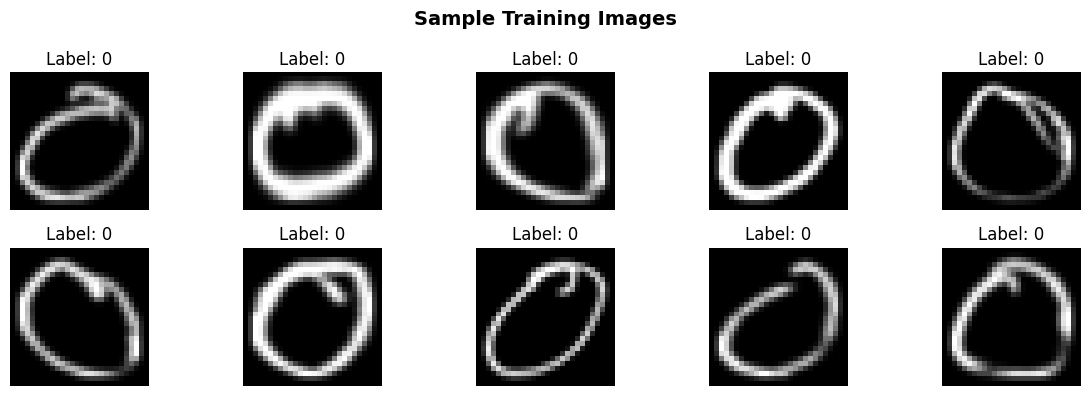

 Sample images displayed successfully.


In [ ]:
#  Visualize sample images from the dataset

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Reshape flattened vector back to 28x28 for display
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')

plt.suptitle("Sample Training Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(" Sample images displayed successfully.")

---
## Task 2: Build the FCN Model

### Architecture we are building:
```
Input (784)  →  Dense(64, sigmoid)  →  Dense(128, sigmoid)  →  Dense(256, sigmoid)  →  Output Dense(10, softmax)
```

- **Dense layer**: every neuron is connected to every neuron in the previous layer
- **sigmoid**: squashes output between 0 and 1 — used for hidden layers here
- **softmax**: converts final scores into probabilities that sum to 1 — ideal for multi-class output

In [ ]:
#  TASK 2 — Build the Fully Connected Model

model = Sequential([
    # INPUT: 784-dimensional vector (flattened 28x28 image)
    # We explicitly tell Keras the input shape here
    Dense(64,  activation='sigmoid', input_shape=(784,), name='hidden_layer_1'),
    # ↑ 1st hidden layer: 64 neurons, sigmoid activation

    Dense(128, activation='sigmoid', name='hidden_layer_2'),
    # ↑ 2nd hidden layer: 128 neurons, sigmoid activation

    Dense(256, activation='sigmoid', name='hidden_layer_3'),
    # ↑ 3rd hidden layer: 256 neurons, sigmoid activation

    Dense(NUM_CLASSES, activation='softmax', name='output_layer')
    # ↑ Output layer: 10 neurons (one per digit class)
    #   softmax converts raw scores to probabilities (all sum to 1.0)
])

# Print a summary of the model architecture
print(" \n Model Architecture Summary:")
model.summary()

 
 Model Architecture Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3: Compile the Model

Compiling sets up 3 things before training:
| Setting | What it does | Our choice |
|---|---|---|
| **Optimizer** | How the model updates weights to reduce error | `adam` |
| **Loss function** | How we measure how wrong the model is | `categorical_crossentropy` |
| **Metrics** | What we want to track during training | `accuracy` |

In [ ]:
#  TASK 3 — Compile the Model

model.compile(
    optimizer='adam',                    # Adam = smart gradient descent
    loss='categorical_crossentropy',     # Standard loss for multi-class classification with one-hot labels
    metrics=['accuracy']                 # We want to monitor accuracy during training
)

print(" Model compiled successfully!")
print("   Optimizer : Adam")
print("   Loss      : Categorical Crossentropy")
print("   Metric    : Accuracy")

 Model compiled successfully!
   Optimizer : Adam
   Loss      : Categorical Crossentropy
   Metric    : Accuracy


---
## Task 4: Train the Model

- **Batch size 128**: the model sees 128 images at once before updating weights
- **20 epochs**: the model goes through the whole dataset 20 times
- **Validation split 0.2**: 20% of training data is held out to check generalization after each epoch
- **EarlyStopping**: automatically stops if validation loss stops improving (prevents overfitting)
- **ModelCheckpoint**: saves the best version of the model during training

In [ ]:
#  TASK 4 — Train the Model

BATCH_SIZE = 128   # Number of samples processed before each weight update
EPOCHS     = 20    # Number of full passes through the training dataset

# ── Callbacks ──
# Callbacks are functions that Keras calls automatically at certain points during training

callbacks = [
    # ModelCheckpoint: saves the model whenever validation accuracy improves
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',   # File where the best model is saved
        monitor='val_accuracy',        # Watch validation accuracy
        save_best_only=True,           # Only save when it's better than before
        verbose=1                      # Print a message when saving
    ),

    # EarlyStopping: stop training if val_loss doesn't improve for 5 consecutive epochs
    keras.callbacks.EarlyStopping(
        monitor='val_loss',    # Watch validation loss
        patience=5,            # Stop after 5 epochs with no improvement
        restore_best_weights=True,  # Restore weights from the best epoch
        verbose=1
    )
]

print(" Starting training...\n")

history = model.fit(
    x_train,             # Training features
    y_train,             # Training labels (one-hot encoded)
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,  # Use 20% of training data for validation
    callbacks=callbacks,
    verbose=1              # Show progress bar for each epoch
)

print("\nTraining complete!")

 Starting training...

Epoch 1/20
 92/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2382 - loss: 2.0055
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4560 - loss: 1.6060 - val_accuracy: 0.0000e+00 - val_loss: 6.9772
Epoch 2/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8169 - loss: 0.6240
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8526 - loss: 0.4970 - val_accuracy: 0.0000e+00 - val_loss: 8.1348
Epoch 3/20
 93/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9079 - loss: 0.2985
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9222 - loss: 0.2628 - val_accuracy: 0.0000e+00 - val_loss: 8.7812
Epoch 4/20
 92/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9454 - loss: 0.1964
Epoch 4: val_accuracy did not 

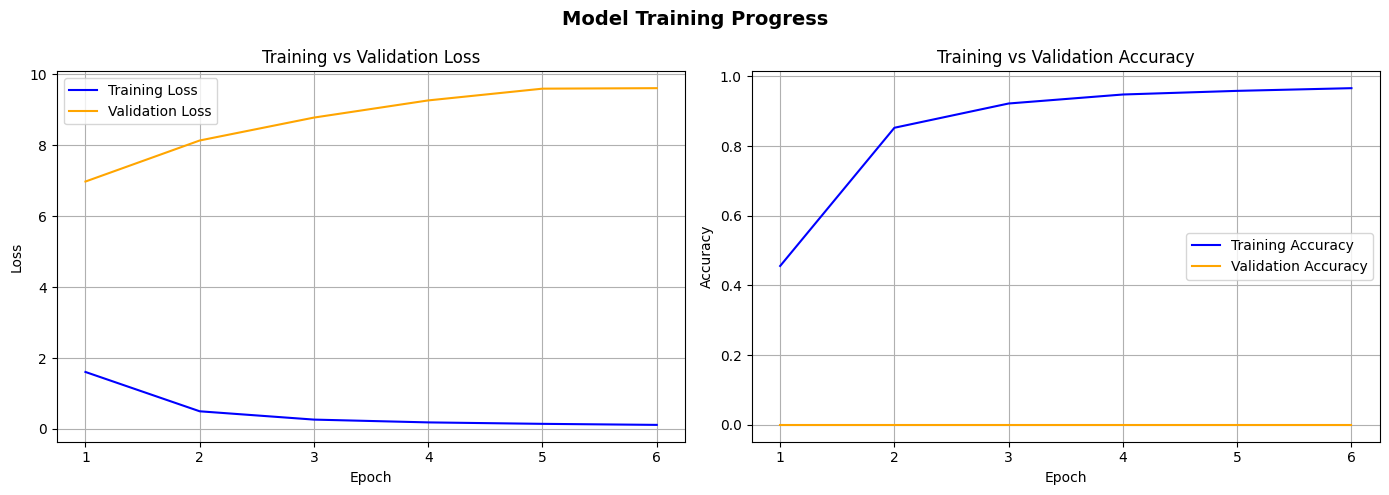

 
 Interpretation guide:
  • If train loss >> val loss  → Model might be UNDERFITTING (needs more epochs/neurons)
  • If val loss >> train loss  → Model might be OVERFITTING (needs regularization/dropout)
  • Both curves close together → Good generalization! 


In [ ]:
#  Visualize Training Progress

# The history object records loss and accuracy for each epoch

train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# ── Plot 1: Loss ──
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss',   color='blue')
plt.plot(epochs_range, val_loss,   label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# ── Plot 2: Accuracy ──
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy',   color='blue')
plt.plot(epochs_range, val_acc,   label='Validation Accuracy', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(" \n Interpretation guide:")
print("  • If train loss >> val loss  → Model might be UNDERFITTING (needs more epochs/neurons)")
print("  • If val loss >> train loss  → Model might be OVERFITTING (needs regularization/dropout)")
print("  • Both curves close together → Good generalization! ")

---
## Task 5: Evaluate the Model

`model.evaluate()` runs the model on the **test set** (data it has never seen) and returns the loss and accuracy.

In [ ]:
#  TASK 5 — Evaluate the Model on Test Data

print("🔍 Evaluating model on test set...\n")

test_loss, test_accuracy = model.evaluate(
    x_test,    # Test features
    y_test,    # Test labels
    verbose=2  # Print one line per batch
)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

print(" \nWhat these numbers mean:")
print("  • Test Accuracy = proportion of test images correctly classified")
print("  • Test Loss     = how wrong the model was on average (lower is better)")

🔍 Evaluating model on test set...

94/94 - 0s - 1ms/step - accuracy: 0.6127 - loss: 2.0515

Test Loss     : 2.0515
Test Accuracy : 61.27%
 
What these numbers mean:
  • Test Accuracy = proportion of test images correctly classified
  • Test Loss     = how wrong the model was on average (lower is better)


---
## Task 6: Save and Load the Model

- **Saving**: preserves the full model (architecture + weights + optimizer state) to disk
- **Loading**: restores the model exactly as it was — no need to retrain!

In [ ]:
#  TASK 6 — Save the Trained Model

save_path = 'devnagari_fcn_model.h5'

model.save(save_path)
print(f" Model saved to: {save_path}")
print("   This file contains: architecture + weights + optimizer state")

 Model saved to: devnagari_fcn_model.h5
   This file contains: architecture + weights + optimizer state


In [ ]:
#  Load the Saved Model and Re-evaluate

# Load the model from disk (as if you were opening it fresh in a new session)
loaded_model = tf.keras.models.load_model("/content/devnagari_fcn_model.h5")
print(f"Model loaded from: {save_path}")

# Re-evaluate using the loaded model to confirm it performs identically
print("\n Re-evaluating loaded model on test set...\n")
loaded_loss, loaded_accuracy = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"\nLoaded Model — Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model — Test Accuracy : {loaded_accuracy * 100:.2f}%")
print("\n Results match the original model → model saved and loaded correctly!")

Model loaded from: devnagari_fcn_model.h5

 Re-evaluating loaded model on test set...

94/94 - 0s - 4ms/step - accuracy: 0.6127 - loss: 2.0515

Loaded Model — Test Loss     : 2.0515
Loaded Model — Test Accuracy : 61.27%

 Results match the original model → model saved and loaded correctly!


---
## Task 7: Make Predictions

- `model.predict()` returns a **probability** for each of the 10 digit classes
- We use `np.argmax()` to pick the class with the **highest probability** as our predicted digit

In [ ]:
#  TASK 7 — Make Predictions on Test Images

print(" Generating predictions on test images...")

# predictions shape: (num_test_samples, 10)
# Each row = probability distribution over 10 digit classes
predictions = model.predict(x_test, verbose=0)

# Convert probability arrays to single predicted digit labels
# np.argmax returns the INDEX of the highest value = the predicted class
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

# Print a few example predictions
print("\nSample Predictions (first 10 test images):")
print(f"{'Index':<8} {'True Label':<14} {'Predicted':<14} {'Correct?'}")
print("-" * 48)
for i in range(10):
    correct = "✅" if predicted_labels[i] == true_labels[i] else "❌"
    print(f"{i:<8} {true_labels[i]:<14} {predicted_labels[i]:<14} {correct}")

# Show what the probabilities look like for a single image
print(f"\n Raw output probabilities for image 0:")
for digit, prob in enumerate(predictions[0]):
    bar = '█' * int(prob * 30)
    print(f"  Digit {digit}: {prob:.4f}  {bar}")

 Generating predictions on test images...

Sample Predictions (first 10 test images):
Index    True Label     Predicted      Correct?
------------------------------------------------
0        0              0              ✅
1        0              0              ✅
2        0              0              ✅
3        0              0              ✅
4        0              0              ✅
5        0              0              ✅
6        0              0              ✅
7        0              0              ✅
8        0              0              ✅
9        0              0              ✅

 Raw output probabilities for image 0:
  Digit 0: 0.6524  ███████████████████
  Digit 1: 0.0682  ██
  Digit 2: 0.0025  
  Digit 3: 0.0033  
  Digit 4: 0.0068  
  Digit 5: 0.0008  
  Digit 6: 0.0203  
  Digit 7: 0.2449  ███████
  Digit 8: 0.0002  
  Digit 9: 0.0006  


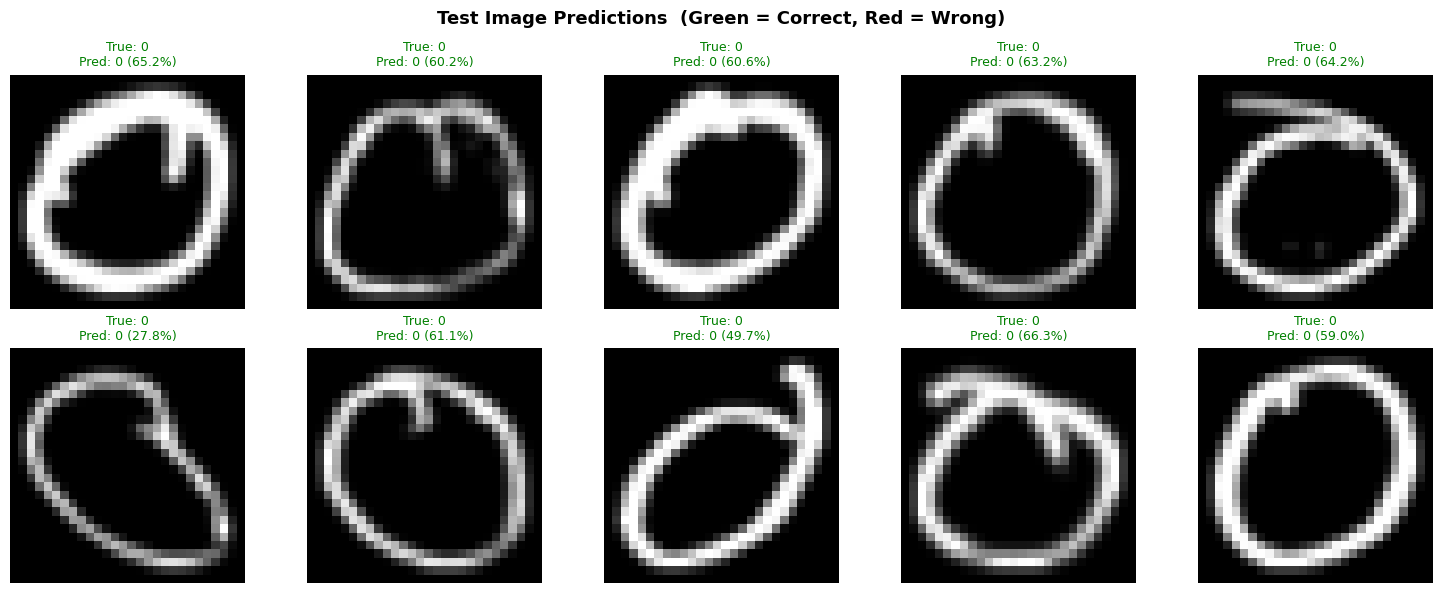


Overall: 1838/3000 correct = 61.27% accuracy


In [ ]:
#  Visualize Predictions on Sample Test Images

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    true_label = true_labels[i]
    pred_label = predicted_labels[i]
    confidence = predictions[i][pred_label] * 100  # Confidence as percentage

    color = 'green' if pred_label == true_label else 'red'
    plt.title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        color=color, fontsize=9
    )
    plt.axis('off')

plt.suptitle('Test Image Predictions  (Green = Correct, Red = Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Overall accuracy breakdown
num_correct = np.sum(predicted_labels == true_labels)
num_total   = len(true_labels)
print(f"\nOverall: {num_correct}/{num_total} correct = {num_correct/num_total*100:.2f}% accuracy")

---
## Summary

| Task | What we did |
|---|---|
| **Task 1** | Loaded Devnagari images from folders, resized to 28×28, normalized, one-hot encoded labels |
| **Task 2** | Built a Sequential FCN: Input → Dense(64) → Dense(128) → Dense(256) → Output(10) |
| **Task 3** | Compiled with Adam optimizer, categorical crossentropy loss, accuracy metric |
| **Task 4** | Trained for up to 20 epochs (batch=128, val_split=0.2) with EarlyStopping & ModelCheckpoint |
| **Task 5** | Evaluated on test set using `model.evaluate()` |
| **Task 6** | Saved model to `.h5`, reloaded and verified same performance |
| **Task 7** | Made predictions with `model.predict()`, converted probabilities → labels with `np.argmax()` |

---
*Worksheet 4 — 6CS012 Artificial Intelligence and Machine Learning*